## 1.5 Approximation au sens des moindres carrés

Soit $m \geq 0$ un nombre entier. Etant donnés <font color=red>$(n+1)$ points</font> 
~~distincts~~ $x_0$, $x_1$,$\dots$ $x_n$ et $(n+1)$ valeurs $y_0$,
$y_1$,$\dots$ $y_n$, on cherche un polynôme $p$
 <font color=red>de degré $m<n$</font> , tel que

$$\sum_{j=0}^n |y_j - p(x_j)|^2 \qquad \text{ soit le plus petit possible}.$$


On appelle **polynôme aux moindres carrés de degré $m$**
le polynôme $\hat{p}_n(x)$ de degré $m$ tel que
\begin{equation}
  \sum_{j=0}^n |y_j - \hat{p}_n(x_j)|^2 \leq \sum_{j=0}^n |y_j - p_n(x_j)|^2
  \qquad \forall p_m(x) \in \mathbb{P}_m
\end{equation}

Nous cherchons les coefficients du polynôme $p(x) = a_0 + a_1 x + ... + a_m x^m$ qui satisfait *au mieux* les $(n+1)$ équations $p(x_k) = y_k, k=0,...,n$, c'est-à-dire

$$a_0 + a_1 x_k + ... + a_m x_k^m = y_k, k=0,...,n$$

Ce système s'écrit sous forme matricielle 

$$\begin{pmatrix}
1 & x_0 & \cdots & x_0^m \\
\vdots   &   &  & \vdots \\
1 & x_n & \cdots & x_n^m
\end{pmatrix}
\begin{pmatrix} a_0 \\ \vdots \\ a_m \end{pmatrix}
=\begin{pmatrix} y_0 \\ \vdots \\ y_n \end{pmatrix}$$

Puisque $m<n$, on ne peut pas résoudre ce système de façon
classique.

Il faut le résoudre au sens des moindres carrés, en considérant:
$$B^T B \mathbf{a} = B^T \mathbf{y}$$

Où $B$ est la matrice $(m+1)\times(n+1)$ du système, $\mathbf{a}\in\mathbf R^{n+1}$ le vecteur des inconnues et $\mathbf{y}\in\mathbf R^{m+1}$
le vecteur des données.

Ce système linéaire est dit
**système d'équations normales**. On peut montrer que les
équations normales sont équivalentes au problème de minimisation.

**Remarque:** *La résolution de ce système demande parfois des méthodes plus avancées que l'élimination de Gauss, comme la factorisation QR. Pour l'instant on va se contenter d'utiliser* `np.linalg.solve`

Pour construire cette matrice, vous pouvez utiliser la fonction
```python
def VandermondeMatrix(x, m=0):
    # Input
    # x : +1 array with interpolation nodes
    # m : degree of the polynomial. If empty, chooses m=size(x)-1 
    # Output
    # Matrix of Vandermonde of size m x n
```
que vous pouvez importer avec la commande
```python
from InterpolationLib import VandermondeMatrix 
```

#### Exemple

On considère un test mécanique pour
établir le lien entre contraintes ($MPa=100 N/cm^2$)
et déformations relatives (cm/cm) d'un échantillon de tissu biologique (disque intervertébral, selon P. Komarek,
Ch. 2 de *Biomechanics of Clinical Aspects of Biomedicine*, 1993, J. Valenta ed., Elsevier).

![title](Figures/disque.png)


On cherche à approximer au sens des moindres carrés avec un polynôme $\hat p_n$ de degré $n=1,2,3$.
Les mesures effectuées sont les suivantes 
```Python
sigma = np.array([0.00, 0.06, 0.14, 0.25, 0.31, 0.47, 0.50, 0.70])
epsilon = np.array([0.00, 0.08, 0.14, 0.20, 0.22, 0.26, 0.27, 0.29])
```


In [1]:
# importing libraries used in this book
import numpy as np
import matplotlib.pyplot as plt

from InterpolationLib import VandermondeMatrix 

In [14]:
# data given:
sigma = np.array([0.00, 0.06, 0.14, 0.25, 0.31, 0.47, 0.50, 0.70])
epsilon = np.array([0.00, 0.08, 0.14, 0.20, 0.22, 0.26, 0.27, 0.29])

# degree of the polynomial
m = 1

B = VandermondeMatrix(sigma,m)

print(B)

# compute coefficients
# >>> COMPLETE HERE <<<
a = np.linalg.solve(np.dot(B.T,B),np.dot(B.T,epsilon))

# print the coefficients on screen
print('The coefficients a_0, ..., a_m are')
print(a)

[[1.   0.  ]
 [1.   0.06]
 [1.   0.14]
 [1.   0.25]
 [1.   0.31]
 [1.   0.47]
 [1.   0.5 ]
 [1.   0.7 ]]
The coefficients a_0, ..., a_m are
[0.06288442 0.39379615]


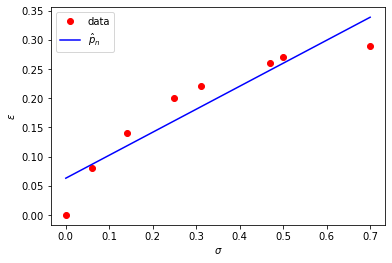

In [19]:
def polynomial(a,x):
    m = a.size-1
    # \hat p = a_0 + a_1 x + ... + a_n x^m
    # is equal to the scalar product between the vectors a and (1, x, ..., x^m) :
    return np.power( np.tile(x, (m+1, 1)).T , np.linspace(0,m,m+1)).dot(a)


# points used to plot the graph, slightly larger than data
# >>> COMPLETE HERE <<<

z = np.linspace(0,0.7,8)

plt.plot(sigma, epsilon, 'ro', z, polynomial(a,z),'b')
plt.xlabel('$\sigma$'); plt.ylabel('$\epsilon$');
plt.legend(['data','$\hat p_n$'])
plt.show()

#### Exercice

Depuis  https://hsso.ch/fr/2012/b/14 on a téléchargé les données de la population suisse dans
le fichier `Data/PopulationSuisse.csv`.

Approximez l'évolution de la population avec un polynôme de degré $n=1,2,3,7$. 

Ensuite faites l'hypothèse de croissance exponentielle de la population, c'est-à-dire $p(x) = e^{a_1 x+a_0}$ où $a_0$ et $a_1$ sont des paramètres. Comment utiliser l'approximation polynômiale dans ce contexte ? 

In [34]:
# Data of the population has been dowloaded from https://hsso.ch/fr/2012/b/14
# into the file Data/PopulationSuisse.csv
import pandas as pd 

# Read data from file 'PopulationSuisse.csv' 
data = pd.read_csv("Data/PopulationSuisse.csv") 
# Preview the first 5 lines of the loaded data 
data.head()


,Année,Population
0,1860,2506784
1,1870,2654394
2,1880,2924702
3,1888,2917754
4,1900,3315443


In [78]:
x = data['Année'].to_numpy()
y = data['Population'].to_numpy()

deg = [1,2,3,7]
B = []
a = []
# >>> COMPLETE HERE <<<
# ... and solve the exercise

for i in range(4) :
    B.append(VandermondeMatrix(x,deg[i]))
    a.append(np.linalg.solve(np.dot(B[i].T,B[i]),np.dot(B[i].T,y)))

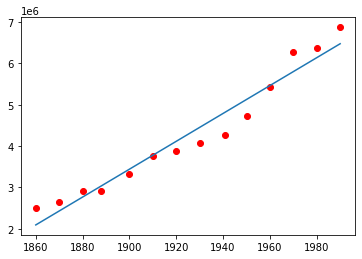

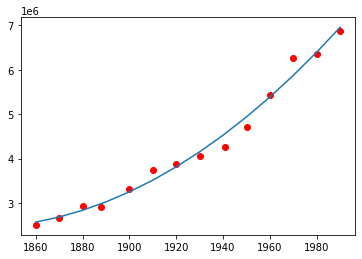

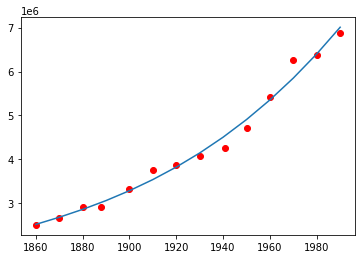

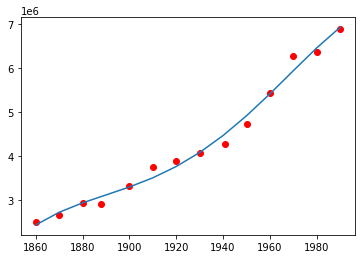

In [79]:
def polynomial(a,x):
    m = a.size-1
    # \hat p = a_0 + a_1 x + ... + a_n x^m
    # is equal to the scalar product between the vectors a and (1, x, ..., x^m) :
    return np.power( np.tile(x, (m+1, 1)).T , np.linspace(0,m,m+1)).dot(a)

z = np.linspace(1860,1990 ,14)

for i in range(4) :
    plt.plot(x, y, 'ro',z,polynomial(a[i],z))
    plt.show()




On assume une croissance exponentielle : $population (x) = C * e^{a_1x} = e^{a_o + a_1 x}$

En d'autres termes: $\log (population) (x) = a_o + a_1 x$


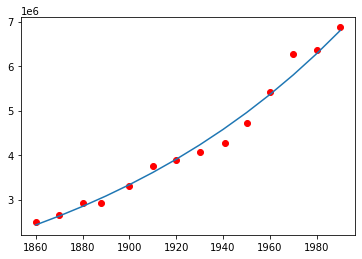

In [80]:
# 
B = VandermondeMatrix(x,1)
a = np.linalg.solve(np.dot(B.T,B),np.dot(B.T,np.log(y)))

plt.plot( x, y, 'ro',z,np.exp(polynomial(a,z)) )
plt.show()